# Malasanita in Italia — Preanalysis v1
**Anno 2022 | Fonti: Ministero della Salute (A, C) + ISTAT (D)**

**Domanda:** Le regioni con meno personale sanitario hanno tassi di mortalita piu alti?

Questa preanalysis esplora la relazione tra dotazione di personale (medici di base e personale ospedaliero) e mortalita regionale su **21 regioni/PA** per l'anno 2022.
Il proxy usato per la mortalita e la **mortalita totale 30+** — non mortalita evitabile (v1). v2 usera Euro-2013 proxy (amenable + preventable). Vedi nota metodologica.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

cwd = Path.cwd().resolve()
project_slug = "malasanita-struttura-mortalita"
candidate_roots = [
    next((path for path in [cwd, *cwd.parents] if path.name == project_slug), None),
    next(
        (
            path for path in [cwd, *cwd.parents]
            if (path / "sources").exists() and (path / "compose").exists()
        ),
        None,
    ),
    cwd / "dataset-incubator" / "preprojects" / "project_candidates" / project_slug,
    cwd / "preprojects" / "project_candidates" / project_slug,
]
project_root = next(
    (
        path.resolve() for path in candidate_roots
        if path is not None and path.exists() and (path / "sources").exists() and (path / "compose").exists()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(f"Non trovo la root di {project_slug} partendo da {cwd}")

repo_root = project_root.parents[2]
MART_PATH = repo_root / "out" / "data" / "mart" / "malasanita_a_strutture_asl" / "2022" / "mart_compose_regioni_v1.parquet"
if not MART_PATH.exists():
    raise FileNotFoundError(f"Parquet MART non trovato: {MART_PATH}")

df = pd.read_parquet(MART_PATH)
print(f"Regioni/PA caricate: {len(df)} | Anno: {df['anno'].iloc[0]}")
print(f"Join C ok: {df['join_c_ok'].sum()}/21 | Join D ok: {df['join_d_ok'].sum()}/21")

Regioni/PA caricate: 21 | Anno: 2022
Join C ok: 21/21 | Join D ok: 21/21


## Panoramica regionale 2022

Tabella ordinata per mortalita decrescente.

In [5]:
cols_display = [
    'regione',
    'medici_mmg_per_100k',
    'infermieri_per_100k',
    'personale_osp_per_100k',
    'posti_letto_previsti_per_100k',
    'decessi_30plus_per_100k_pop_totale',
]

tab = (
    df[cols_display]
    .sort_values('decessi_30plus_per_100k_pop_totale', ascending=False)
    .reset_index(drop=True)
)
tab.columns = ['Regione', 'MMG/100k', 'Infermieri/100k', 'Pers.osp/100k', 'PL/100k', 'Decessi30+/100k']
tab.index += 1
tab

,Regione,MMG/100k,Infermieri/100k,Pers.osp/100k,PL/100k,Decessi30+/100k
1,LIGURIA,68.18,435.19,44.39,262.39,1566.56
2,MOLISE,82.49,340.24,836.56,316.62,1425.98
3,PIEMONTE,65.50,272.56,180.79,279.39,1363.26
4,UMBRIA,78.95,327.55,360.27,304.96,1326.72
5,TOSCANA,76.16,341.26,238.29,219.40,1312.03
6,FRIULI VENEZIA GIULIA,61.78,270.87,284.18,215.38,1302.56
7,ABRUZZO,75.71,426.43,310.75,242.41,1294.41
8,MARCHE,67.51,261.10,167.57,247.86,1292.61
9,BASILICATA,78.35,185.89,172.40,141.36,1287.03
10,SARDEGNA,64.44,246.88,356.62,267.04,1260.92


## Numeri chiave

In [6]:
mort = df['decessi_30plus_per_100k_pop_totale']
mmg  = df['medici_mmg_per_100k']
inf  = df['infermieri_per_100k']

r_mort_max = df.loc[mort.idxmax(), 'regione']
r_mort_min = df.loc[mort.idxmin(), 'regione']
r_mmg_max  = df.loc[mmg.idxmax(),  'regione']
r_mmg_min  = df.loc[mmg.idxmin(),  'regione']
r_inf_max  = df.loc[inf.idxmax(),  'regione']
r_inf_min  = df.loc[inf.idxmin(),  'regione']

print("--- MORTALITA 30+ per 100k (proxy totale) ---")
print(f"  Piu alta: {r_mort_max:<30} {mort.max():.0f}")
print(f"  Piu bassa: {r_mort_min:<29} {mort.min():.0f}")
print(f"  Scarto max-min: {mort.max()-mort.min():.0f} decessi per 100k")
print(f"  Media nazionale: {mort.mean():.0f}")
print()
print("--- MMG per 100k ---")
print(f"  Piu alto: {r_mmg_max:<30} {mmg.max():.1f}")
print(f"  Piu basso: {r_mmg_min:<29} {mmg.min():.1f}")
print()
print("--- INFERMIERI per 100k ---")
print(f"  Piu alto: {r_inf_max:<30} {inf.max():.0f}")
print(f"  Piu basso: {r_inf_min:<29} {inf.min():.0f}")

--- MORTALITA 30+ per 100k (proxy totale) ---
  Piu alta: LIGURIA                        1567
  Piu bassa: PROV. AUTON. BOLZANO          908
  Scarto max-min: 659 decessi per 100k
  Media nazionale: 1226

--- MMG per 100k ---
  Piu alto: MOLISE                         82.5
  Piu basso: PROV. AUTON. BOLZANO          54.1

--- INFERMIERI per 100k ---
  Piu alto: LIGURIA                        435
  Piu basso: VENETO                        58


## Scatter - Medici di base (MMG) vs mortalita 30+

Asse X: MMG per 100k residenti (fonte A) | Asse Y: decessi 30+ per 100k popolazione totale (fonte D)

**Ipotesi iniziale:** una correlazione negativa sarebbe coerente con l'idea che una maggiore dotazione territoriale si associ a minore mortalita. Questa lettura resta solo descrittiva e non implica causalita.

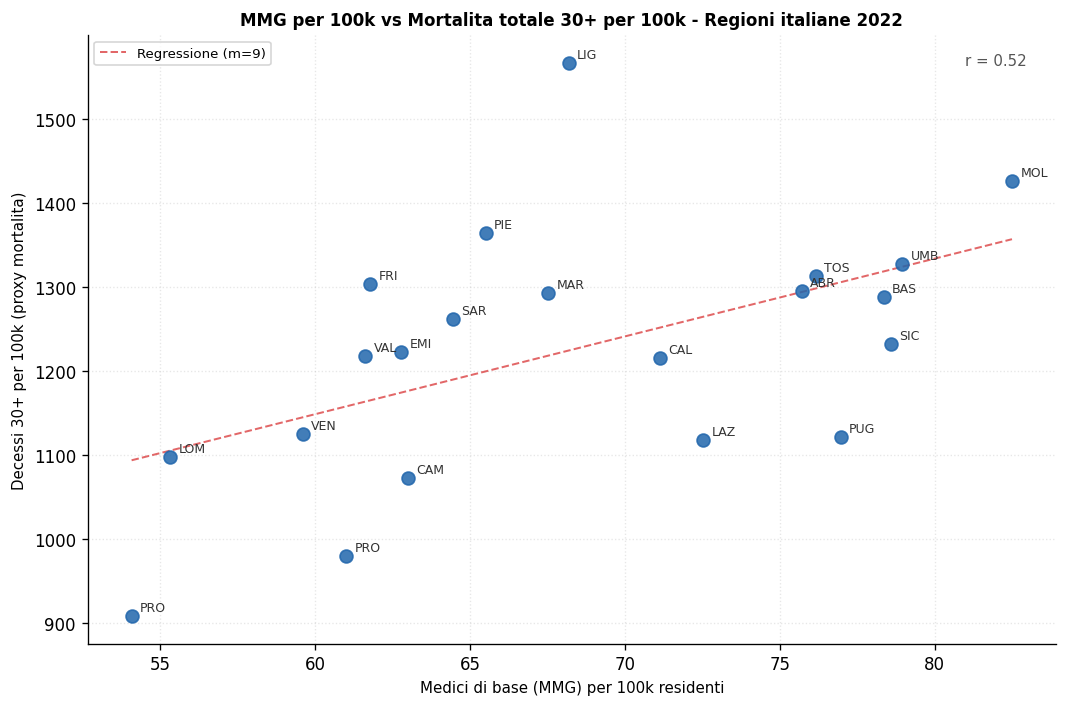

In [7]:
def sigla(nome):
    """Abbreviazione regione per etichetta scatter."""
    m = {
        'Valle': 'VDA', 'Bolzano': 'BZ', 'Trento': 'TN',
        'Friuli': 'FVG', 'Emilia': 'ER', 'Toscana': 'TOS',
        'Umbria': 'UMB', 'Liguria': 'LIG', 'Lombardia': 'LOM',
        'Piemonte': 'PIE', 'Veneto': 'VEN', 'Marche': 'MAR',
        'Lazio': 'LAZ', 'Abruzzo': 'ABR', 'Molise': 'MOL',
        'Campania': 'CAM', 'Puglia': 'PUG', 'Basilicata': 'BAS',
        'Calabria': 'CAL', 'Sicilia': 'SIC', 'Sardegna': 'SAR',
    }
    for k, v in m.items():
        if k in nome:
            return v
    return nome[:3].upper()


def scatter_plot(ax, x_col, y_col, x_label, title, df):
    x = df[x_col]
    y = df[y_col]

    ax.scatter(x, y, color='#2166ac', alpha=0.85, s=60, zorder=3)

    # Linea di regressione
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='#d62728', linewidth=1.2,
            linestyle='--', alpha=0.7, label=f'Regressione (m={m:.0f})')

    # Correlazione
    r = np.corrcoef(x, y)[0, 1]
    ax.text(0.97, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='#555555')

    # Etichette regioni
    for _, row in df.iterrows():
        ax.annotate(
            sigla(row['regione']),
            (row[x_col], row[y_col]),
            textcoords='offset points', xytext=(5, 3),
            fontsize=7.5, color='#333333'
        )

    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel('Decessi 30+ per 100k (proxy mortalita)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, linestyle=':')


fig, ax = plt.subplots(figsize=(9, 6))
scatter_plot(
    ax,
    x_col='medici_mmg_per_100k',
    y_col='decessi_30plus_per_100k_pop_totale',
    x_label='Medici di base (MMG) per 100k residenti',
    title='MMG per 100k vs Mortalita totale 30+ per 100k - Regioni italiane 2022',
    df=df
)
plt.tight_layout()
plt.show()

## Scatter - Infermieri (personale ospedaliero) vs mortalita 30+

Asse X: infermieri per 100k (fonte C) | Asse Y: decessi 30+ per 100k (fonte D)

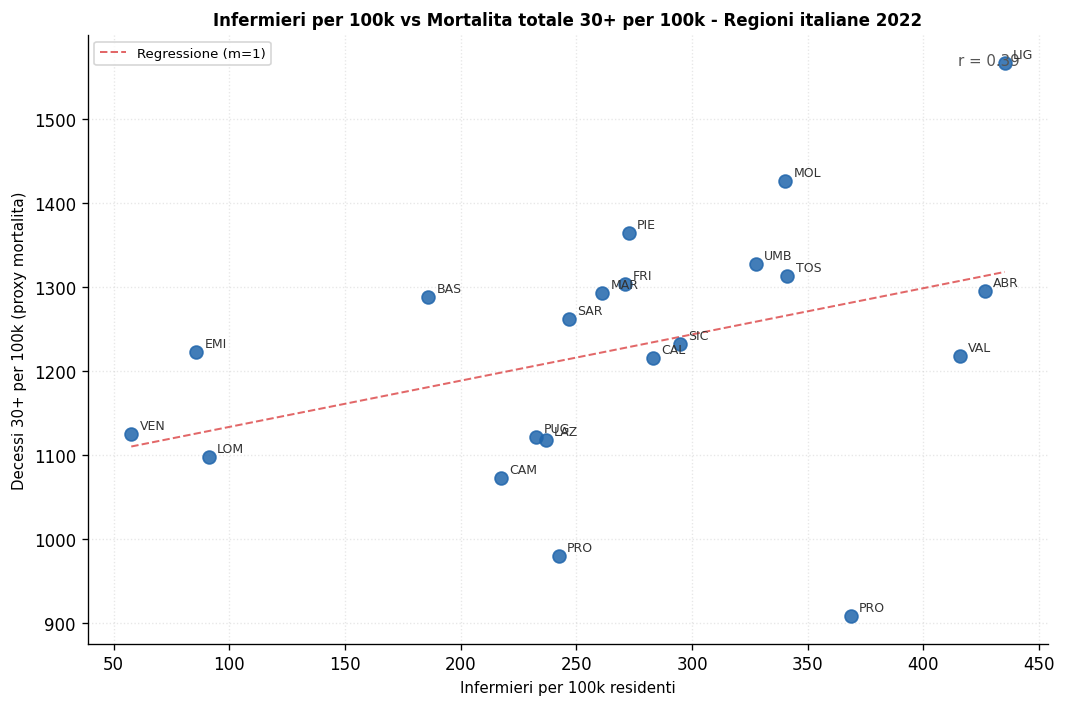

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_plot(
    ax,
    x_col='infermieri_per_100k',
    y_col='decessi_30plus_per_100k_pop_totale',
    x_label='Infermieri per 100k residenti',
    title='Infermieri per 100k vs Mortalita totale 30+ per 100k - Regioni italiane 2022',
    df=df
)
plt.tight_layout()
plt.show()

## Scatter - Posti letto per 100k vs mortalita 30+

Asse X: posti letto previsti per 100k (fonte C) | Asse Y: decessi 30+ per 100k (fonte D)

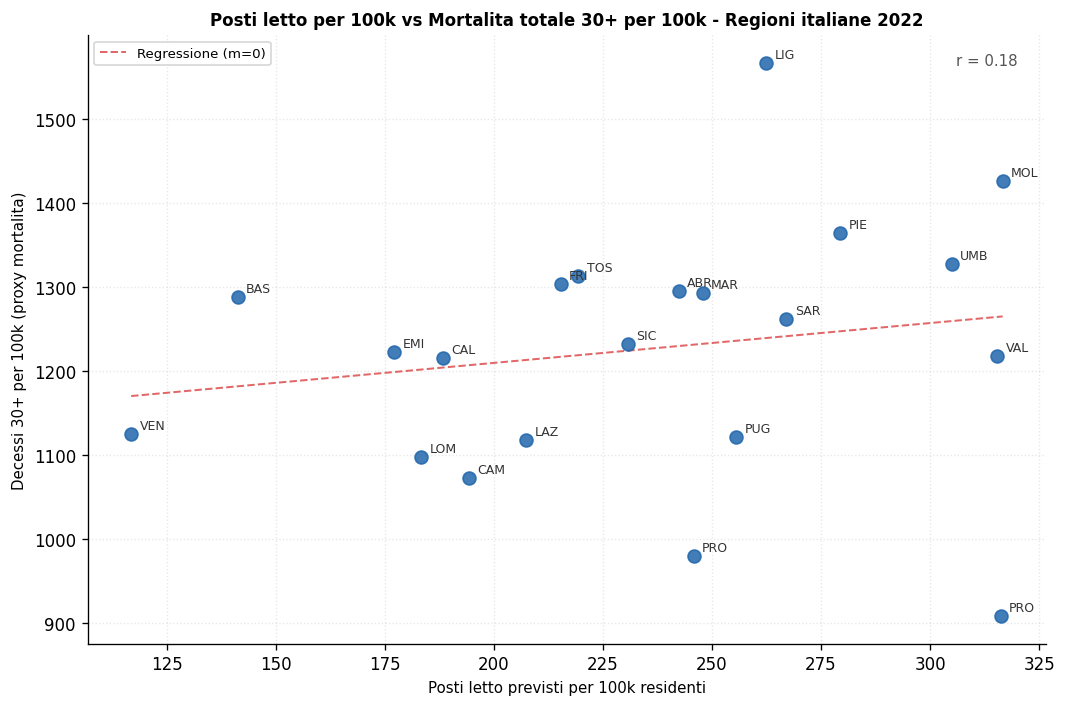

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_plot(
    ax,
    x_col='posti_letto_previsti_per_100k',
    y_col='decessi_30plus_per_100k_pop_totale',
    x_label='Posti letto previsti per 100k residenti',
    title='Posti letto per 100k vs Mortalita totale 30+ per 100k - Regioni italiane 2022',
    df=df
)
plt.tight_layout()
plt.show()

## Nota di lettura

Questa e una lettura descrittiva intermedia. La **risposta finale alla domanda analitica** e riportata solo nell'ultima sezione del notebook, dopo tutte le visual aggiuntive.


---


## Visual aggiuntive per rispondere meglio alla domanda

Le visual sotto puntano a una risposta piu diretta: quanto la mortalita 30+ si muove insieme alla dotazione sanitaria regionale?


### 1) Scatter chiave: personale ospedaliero totale vs mortalita


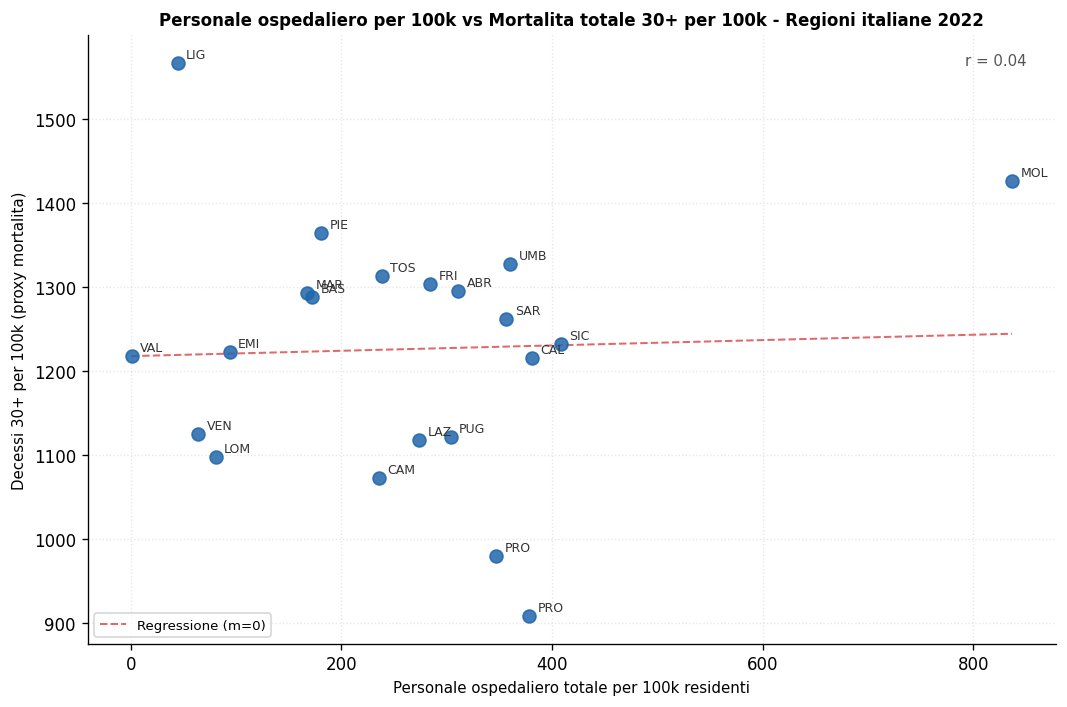

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_plot(
    ax,
    x_col='personale_osp_per_100k',
    y_col='decessi_30plus_per_100k_pop_totale',
    x_label='Personale ospedaliero totale per 100k residenti',
    title='Personale ospedaliero per 100k vs Mortalita totale 30+ per 100k - Regioni italiane 2022',
    df=df
)
plt.tight_layout()
plt.show()


### 2) Quadranti: alta/bassa dotazione vs alta/bassa mortalita


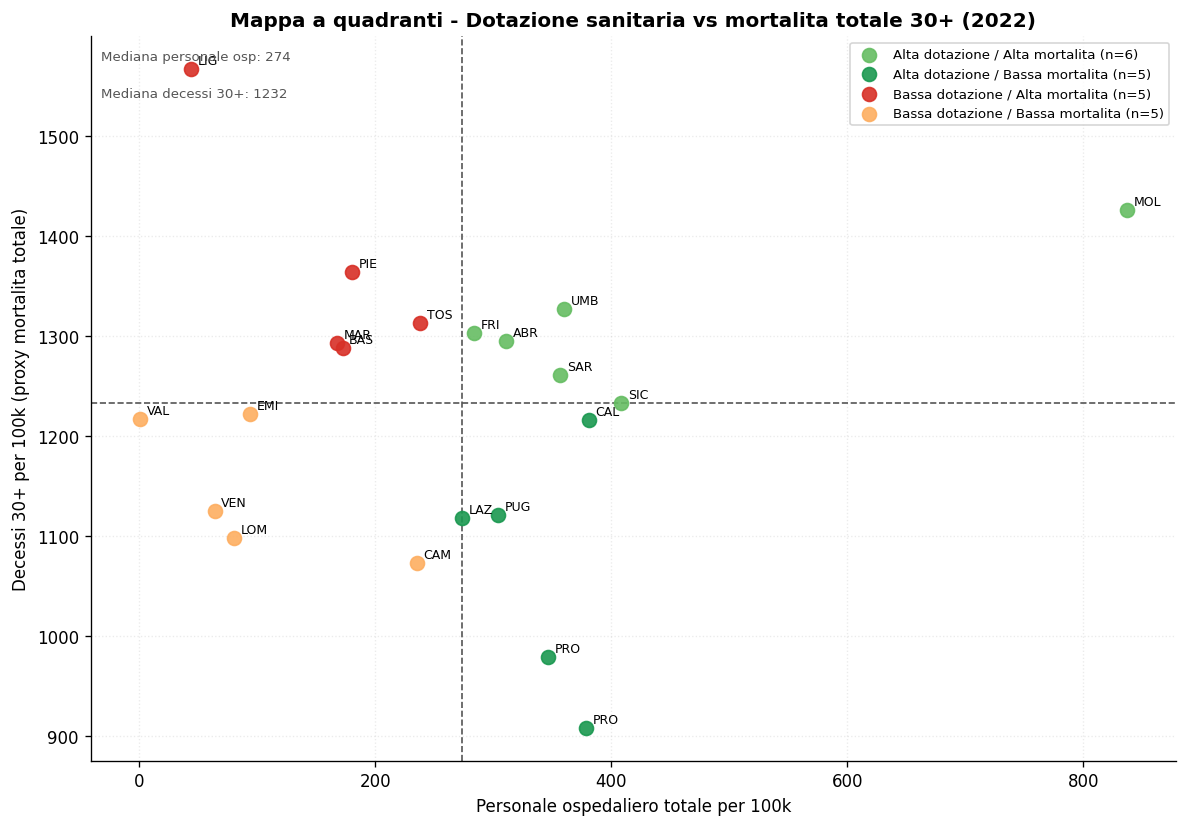

,Regioni
Quadrante,
Alta dotazione / Alta mortalita,6
Bassa dotazione / Alta mortalita,5
Bassa dotazione / Bassa mortalita,5
Alta dotazione / Bassa mortalita,5


In [11]:
x_col = 'personale_osp_per_100k'
y_col = 'decessi_30plus_per_100k_pop_totale'
x = df[x_col]
y = df[y_col]
x_med = x.median()
y_med = y.median()

quad = df.copy()
quad['quadrante'] = np.select(
    [
        (quad[x_col] >= x_med) & (quad[y_col] < y_med),
        (quad[x_col] >= x_med) & (quad[y_col] >= y_med),
        (quad[x_col] < x_med) & (quad[y_col] >= y_med),
        (quad[x_col] < x_med) & (quad[y_col] < y_med),
    ],
    ['Alta dotazione / Bassa mortalita', 'Alta dotazione / Alta mortalita', 'Bassa dotazione / Alta mortalita', 'Bassa dotazione / Bassa mortalita'],
    default='Non classificato'
)

colors = {
    'Alta dotazione / Bassa mortalita': '#1a9850',
    'Alta dotazione / Alta mortalita': '#66bd63',
    'Bassa dotazione / Alta mortalita': '#d73027',
    'Bassa dotazione / Bassa mortalita': '#fdae61',
}

fig, ax = plt.subplots(figsize=(10, 7))
for q_name, g in quad.groupby('quadrante'):
    ax.scatter(g[x_col], g[y_col], s=70, alpha=0.9, color=colors[q_name], label=f"{q_name} (n={len(g)})", zorder=3)
    for _, r in g.iterrows():
        ax.annotate(sigla(r['regione']), (r[x_col], r[y_col]), textcoords='offset points', xytext=(4, 3), fontsize=7.5)

ax.axvline(x_med, color='#555555', linestyle='--', linewidth=1)
ax.axhline(y_med, color='#555555', linestyle='--', linewidth=1)
ax.text(0.01, 0.98, f'Mediana personale osp: {x_med:.0f}', transform=ax.transAxes, va='top', fontsize=8, color='#555555')
ax.text(0.01, 0.93, f'Mediana decessi 30+: {y_med:.0f}', transform=ax.transAxes, va='top', fontsize=8, color='#555555')
ax.set_xlabel('Personale ospedaliero totale per 100k')
ax.set_ylabel('Decessi 30+ per 100k (proxy mortalita totale)') 
ax.set_title('Mappa a quadranti - Dotazione sanitaria vs mortalita totale 30+ (2022)', fontweight='bold')
ax.grid(True, alpha=0.25, linestyle=':')
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

quad_counts = quad['quadrante'].value_counts().rename_axis('Quadrante').to_frame('Regioni')
quad_counts


### 3) Rank-dumbbell: ranking dotazione vs ranking mortalita


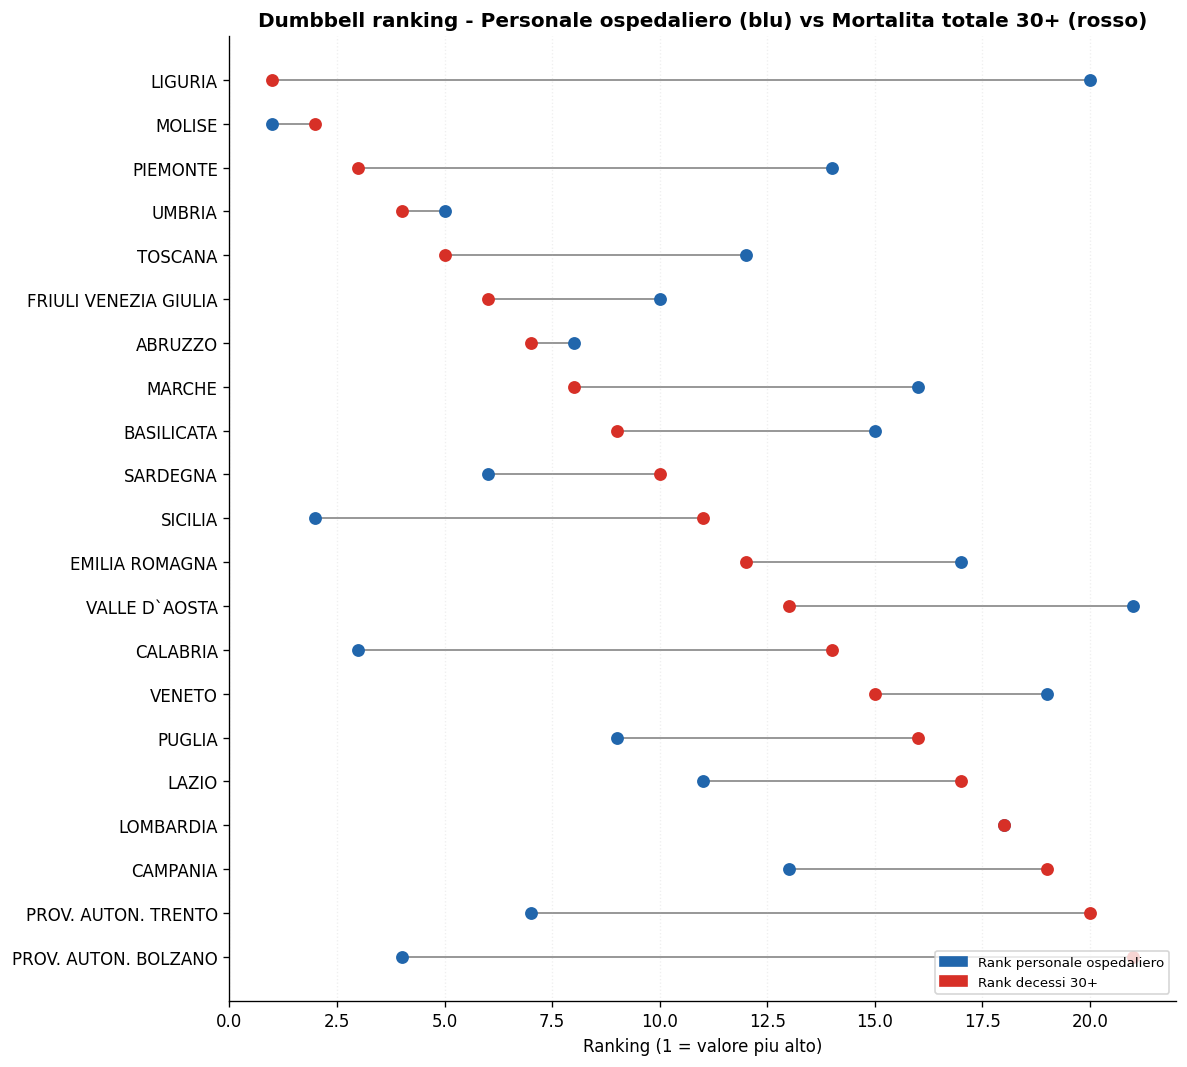

,regione,rank_personale,rank_mortalita
7,LIGURIA,20.0,1.0
14,MOLISE,1.0,2.0
0,PIEMONTE,14.0,3.0
10,UMBRIA,5.0,4.0
9,TOSCANA,12.0,5.0
6,FRIULI VENEZIA GIULIA,10.0,6.0
13,ABRUZZO,8.0,7.0
11,MARCHE,16.0,8.0
17,BASILICATA,15.0,9.0
20,SARDEGNA,6.0,10.0


In [12]:
rank_df = df[['regione', 'personale_osp_per_100k', 'decessi_30plus_per_100k_pop_totale']].copy()
rank_df['rank_personale'] = rank_df['personale_osp_per_100k'].rank(method='min', ascending=False)
rank_df['rank_mortalita'] = rank_df['decessi_30plus_per_100k_pop_totale'].rank(method='min', ascending=False)
rank_df = rank_df.sort_values('rank_mortalita')

fig, ax = plt.subplots(figsize=(10, 9))
y_pos = np.arange(len(rank_df))
for i, (_, r) in enumerate(rank_df.iterrows()):
    ax.plot([r['rank_personale'], r['rank_mortalita']], [i, i], color='#999999', linewidth=1.2, zorder=1)
    ax.scatter(r['rank_personale'], i, color='#2166ac', s=45, zorder=3)
    ax.scatter(r['rank_mortalita'], i, color='#d73027', s=45, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(rank_df['regione'])
ax.invert_yaxis()
ax.set_xlabel('Ranking (1 = valore piu alto)')
ax.set_title('Dumbbell ranking - Personale ospedaliero (blu) vs Mortalita totale 30+ (rosso)', fontweight='bold')
ax.grid(axis='x', alpha=0.2, linestyle=':')
legend_handles = [
    mpatches.Patch(color='#2166ac', label='Rank personale ospedaliero'),
    mpatches.Patch(color='#d73027', label='Rank decessi 30+'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

rank_df[['regione', 'rank_personale', 'rank_mortalita']].head(10)


### 4) Heatmap correlazioni tra indicatori principali


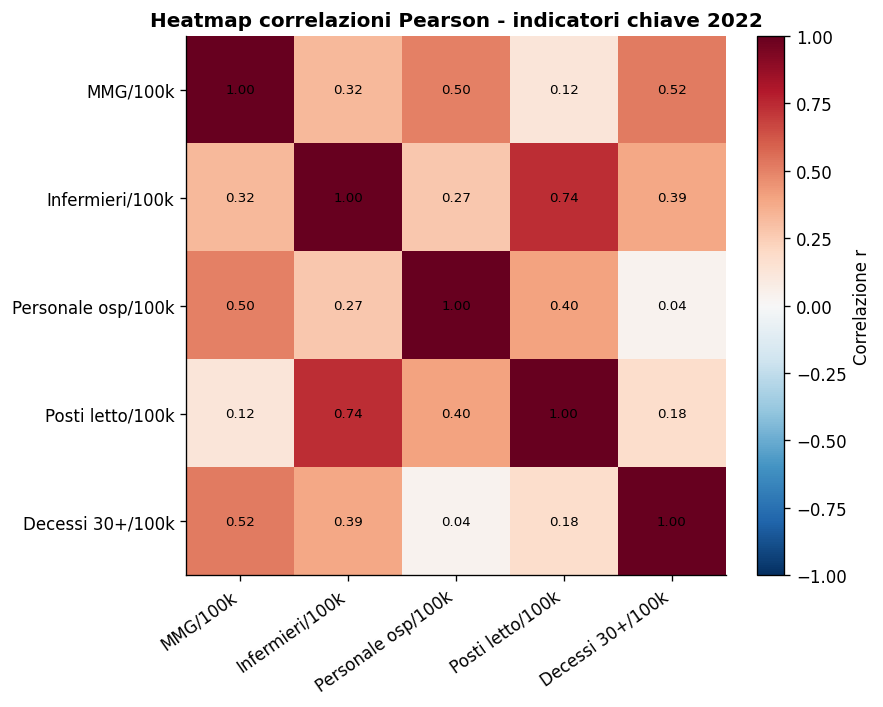

,medici_mmg_per_100k,infermieri_per_100k,personale_osp_per_100k,posti_letto_previsti_per_100k,decessi_30plus_per_100k_pop_totale
medici_mmg_per_100k,1.000000,0.320926,0.500984,0.117708,0.519187
infermieri_per_100k,0.320926,1.000000,0.271606,0.739400,0.387054
personale_osp_per_100k,0.500984,0.271606,1.000000,0.404830,0.038346
posti_letto_previsti_per_100k,0.117708,0.739400,0.404830,1.000000,0.178056
decessi_30plus_per_100k_pop_totale,0.519187,0.387054,0.038346,0.178056,1.000000


In [13]:
corr_cols = [
    'medici_mmg_per_100k',
    'infermieri_per_100k',
    'personale_osp_per_100k',
    'posti_letto_previsti_per_100k',
    'decessi_30plus_per_100k_pop_totale',
]
corr = df[corr_cols].corr()

labels = [
    'MMG/100k',
    'Infermieri/100k',
    'Personale osp/100k',
    'Posti letto/100k',
    'Decessi 30+/100k',
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_yticklabels(labels)
ax.set_title('Heatmap correlazioni Pearson - indicatori chiave 2022', fontweight='bold')

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8, color='black')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlazione r')
plt.tight_layout()
plt.show()
corr


## Risposta sintetica alla domanda analitica

Con il dataset 2022 e il proxy di **mortalita totale 30+**, le correlazioni di Pearson tra dotazione sanitaria e mortalita risultano **non negative**:

| Indicatore | r con mortalita 30+ |
|---|---|
| MMG/100k | **+0.52** |
| Infermieri/100k | **+0.39** |
| Personale ospedaliero/100k | **+0.04** |
| Posti letto/100k | **+0.18** |

Il segno generale e opposto a quello ipotizzato: con questo proxy non emerge una relazione descrittiva semplice tra piu dotazione sanitaria e meno mortalita.

Va pero distinta l'intensita del segnale: con **n=21** solo `MMG/100k` (`r = +0.52`) mostra un'associazione moderata da discutere; `personale_ospedaliero/100k` (`r = +0.04`) e `posti letto/100k` (`r = +0.18`) sono da trattare come valori vicini al rumore descrittivo, non come segnali interpretabili.

**La risposta con questo proxy e: no, o almeno non nel senso ipotizzato.**

### Perche? Il confondente demografico

Le regioni con mortalita 30+ piu alta (Liguria, Piemonte, FVG) sono anche le **piu anziane d'Italia**.
Hanno piu infrastruttura sanitaria *perche* ne hanno bisogno, e piu mortalita *perche* la popolazione e vecchia.
La mortalita totale 30+ non e age-adjusted: cattura struttura demografica, non performance del sistema sanitario.

### Outlier significativi

- **Liguria**: mortalita #1 e personale osp rank #20. Caso da leggere soprattutto insieme al profilo demografico regionale, non come conferma autonoma dell'ipotesi sanitaria.
- **Molise**: personale osp rank #1 con `836.56` per 100k. Prima di interpretarlo come finding, va verificato come possibile outlier o problema di denominatore/copertura nella fonte C.
- **Valle d'Aosta**: `personale_osp_per_100k = 0.81`, valore implausibile da trattare come possibile buco di copertura della fonte C.
- **Bolzano/Trento**: mortalita piu bassa, dotazione variabile.

### v2 — decisione metodologica presa

Framework adottato: **Euro-2013 proxy** (Eurostat, Avoidable mortality — amenable and preventable).

12 cause mappate dalla fonte D: Sepsi, Tumori colon/retto, Tumori polmone, Tumore seno, Diabete,
Malattie ischemiche cuore, Malattie cerebrovascolari, Malattie ipertensive, Influenza e Polmonite,
Malattie croniche vie respiratorie, Cirrosi/epatite cronica, Cause esterne.

Mart D aggiornato con il nuovo filtro. Prossimo passo: rieseguire la pipeline e confrontare i risultati.

---

*Nota metodologica:*
*- Questa preanalysis (v1) usa un proxy di mortalita totale (30+, cod_causa=25, tutte le cause) non standardizzato per eta.*
*- cod_classe_eta=9 = fascia 30 anni e oltre (perimetro dichiarato esplicitamente).*
*- I risultati v1 non sono interpretabili come valutazione causale della performance sanitaria regionale.*
*- v2 usera mortalita evitabile Euro-2013 proxy: tasso grezzo 30+ su 12 cause amenable/preventable.*
*  Il tasso risultante e grezzo (non age-standardized) — la distinzione e mantenuta nel naming del campo.*
*- I dati Ministero della Salute sono fermi al 2022 (gap temporale strutturale): parte della narrativa, documentato.*
*- Emilia-Romagna in questa v1 e inclusa nelle tabelle e nelle visual del notebook; eventuali esclusioni metodologiche vanno applicate esplicitamente anche nel codice, non solo dichiarate a testo.*